# Phase 2c: XGBoost
## Telco Customer Churn Prediction

**Model**: XGBoost Classifier with scale_pos_weight for imbalance  
**Goal**: High-performance gradient boosting (often best on this dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
np.random.seed(42)
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Load processed data + preprocessor to recover feature names
preprocessor = joblib.load('../src/models/preprocessor.joblib')
feature_names = preprocessor.get_feature_names_out()

X_train = pd.read_csv('../data/processed/X_train_processed.csv', header=0)
X_train.columns = feature_names

X_test = pd.read_csv('../data/processed/X_test_processed.csv', header=0)
X_test.columns = feature_names

y_train = pd.read_csv('../data/processed/y_train.csv').iloc[:, 0].astype(int)
y_test = pd.read_csv('../data/processed/y_test.csv').iloc[:, 0].astype(int)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

Train: (5634, 39) | Test: (1409, 39)
Churn rate train: 26.5% | test: 26.5%


In [3]:
# Calculate scale_pos_weight for imbalance handling
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost model
model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='aucpr',           # good for imbalanced data
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

# Hyperparameter grid (focused & efficient)
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [0, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
print("✅ Best params:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


✅ Best params: {'subsample': 0.7, 'reg_lambda': 10, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV F1: 0.6335


In [4]:
# Final model
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=== Test Set Performance ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"F1-score     : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC      : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC       : {average_precision_score(y_test, y_prob):.4f}")

=== Test Set Performance ===
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

F1-score     : 0.6305
ROC-AUC      : 0.8478
PR-AUC       : 0.6581


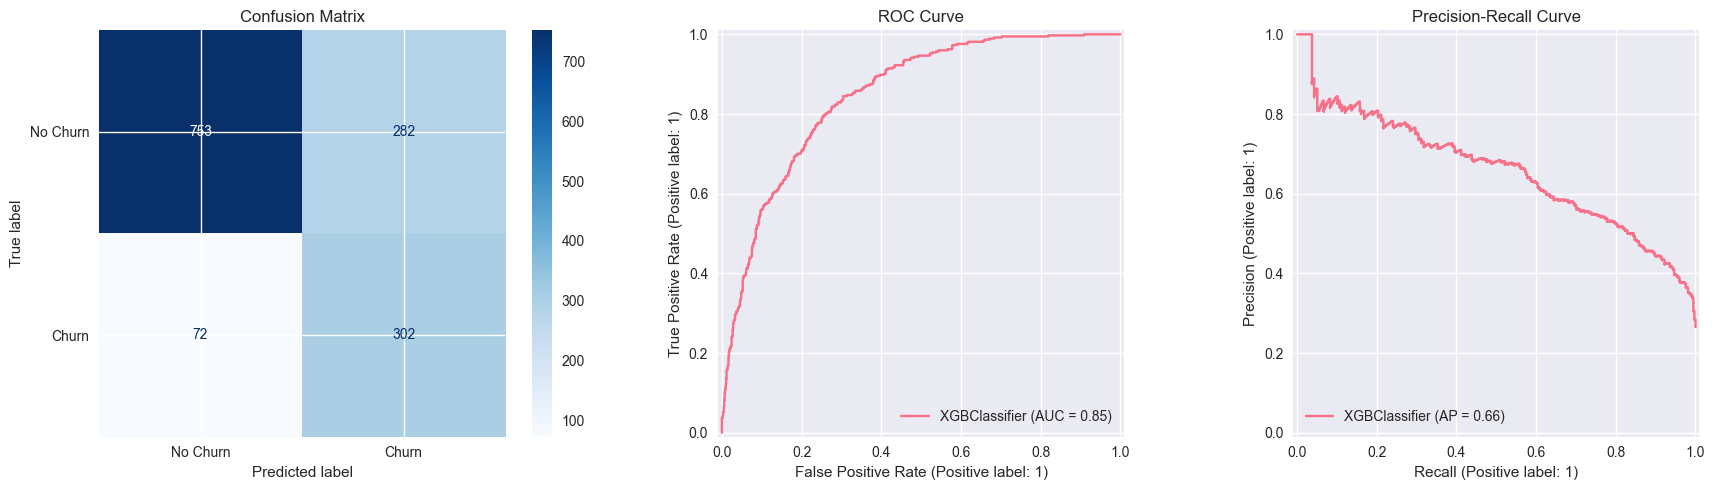

In [5]:
# Visualisations

# Ensure directories exist
Path('../src/figures').mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('../src/figures/xgboost_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

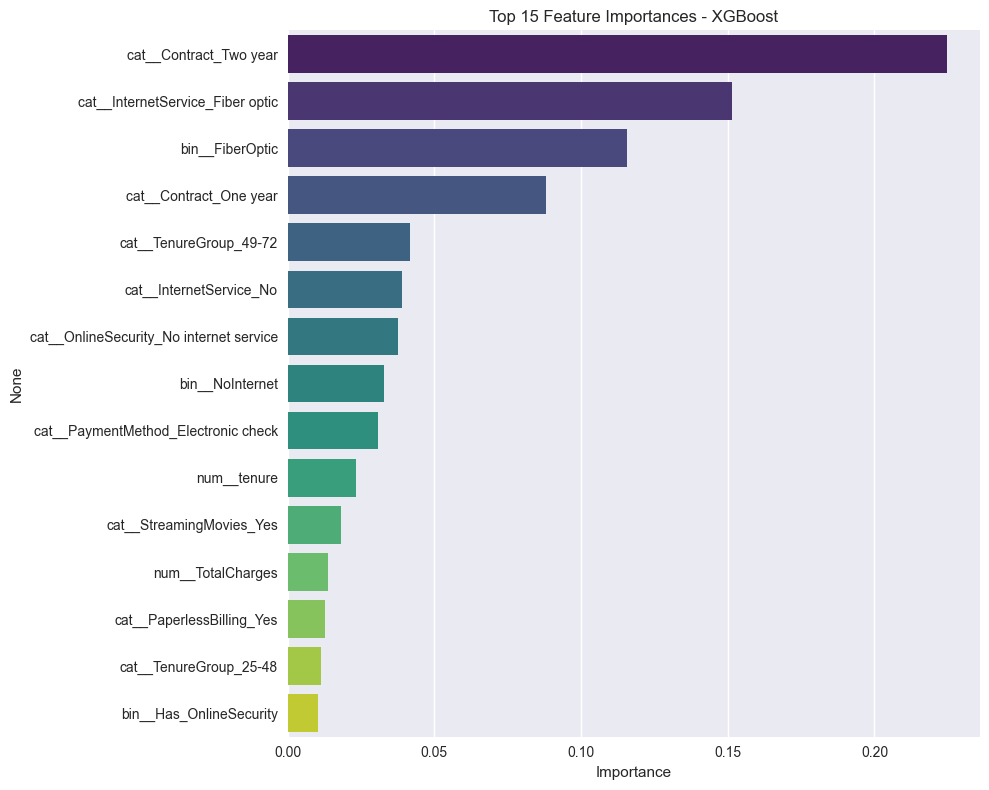

In [6]:
# Feature Importance (top 15)
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top15.values, y=top15.index, palette='viridis')
plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../src/figures/xgboost_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
# Save artifacts
Path('../src/models').mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, '../src/models/xgboost.joblib')
joblib.dump(search, '../src/models/xgb_search.joblib')

print("✅ XGBoost model saved successfully!")

✅ XGBoost model saved successfully!
